# Taller 2 — Matrices, Tensores y Clasificación con MNIST

**Asignatura:** Machine Learning  
**Nombre del estudiante:**  Areliz Isla
**Sección:**  MLY1101
**Fecha:**  20-08-2026

> Complete las secciones indicadas. El notebook debe poder ejecutarse completamente utilizando **Ejecutar todas**.

## Objetivo

Aplicar estructuras de **matrices y tensores** sobre imágenes de MNIST, comparar estrategias de clasificación multiclase **OvO y OvR** considerando precisión y tiempo de ejecución, y construir un sistema de eliminación de ruido mediante **KNN multisalida**.

## Consideraciones generales

- Utilice `mnist_784` desde `fetch_openml`.
- Explore las **70.000 imágenes**.
- Separe las primeras **60.000** para entrenamiento y las últimas **10.000** para prueba.
- Puede utilizar una muestra de entrenamiento en modelos que requieran mayor tiempo de cómputo, pero debe indicarlo.
- Para comparar OvO y OvR debe utilizar el **mismo clasificador base** y la **misma cantidad de observaciones**.
- La imagen de la última parte debe ser una **imagen propia**, no extraída directamente de MNIST.

## Setup

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier

plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=12)

def plot_digit(image_data, title=None):
    image = np.array(image_data).reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    if title:
        plt.title(title)

# Parte 1 — Exploración de matrices y tensores

## 1. Cargando MNIST

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

# TODO: Imprima las dimensiones de X e y
display(X)
display(y)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

### Respuesta

Explique qué representa una fila de `X` y qué representa un valor de `y`.

una fila de X representa una única imagen de un digito escrito a mano.
Y un valor de y representa la etiqueta o el digito real (del 0 al 9) que la imagen correspondiente en X representa.

## 2. Imagen como vector y matriz

Seleccione al menos 3 imágenes. Para cada una muestre:

- etiqueta;
- shape como vector;
- shape como matriz 28×28;
- imagen resultante.

Etiqueta: 5
Shape vector: (784,)
Shape matriz: (28, 28)


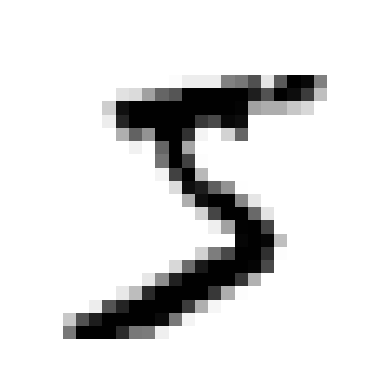

In [3]:
# EJEMPLO
indice = 0

vector = X[indice]
matriz = vector.reshape(28, 28)

print("Etiqueta:", y[indice])
print("Shape vector:", vector.shape)
print("Shape matriz:", matriz.shape)

plot_digit(vector)
plt.show()

# TODO: Repita el análisis con al menos otras 2 imágenes.

Etiqueta: 0
Shape vector: (784,)
Shape matriz: (28, 28)


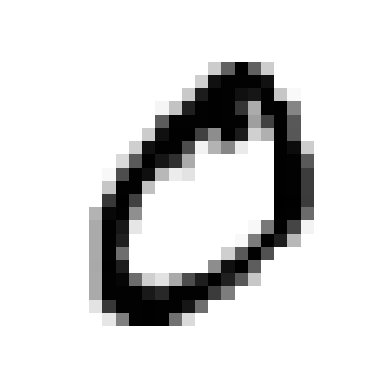

In [4]:
indice = 1

vector = X[indice]
matriz = vector.reshape(28, 28)

print("Etiqueta:", y[indice])
print("Shape vector:", vector.shape)
print("Shape matriz:", matriz.shape)

plot_digit(vector)
plt.show()

Etiqueta: 4
Shape vector: (784,)
Shape matriz: (28, 28)


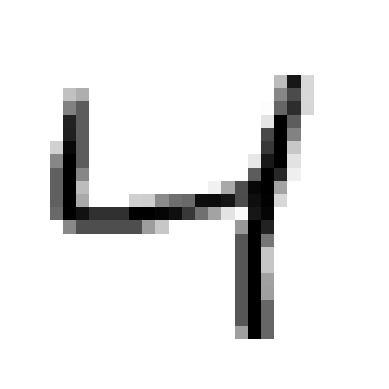

In [5]:
indice = 2

vector = X[indice]
matriz = vector.reshape(28, 28)

print("Etiqueta:", y[indice])
print("Shape vector:", vector.shape)
print("Shape matriz:", matriz.shape)

plot_digit(vector)
plt.show()

## 3. Construcción del tensor de imágenes

Transforme `X` desde `(70000, 784)` a `(70000, 28, 28)`.

In [6]:
X_tensor = X.reshape(-1, 28, 28)
print(X_tensor.shape)

(70000, 28, 28)


### Respuesta

Explique qué representa cada dimensión del tensor.

La primera dimension (700000) representa el número total de imágenes en el conjunto de datos.

La segunda dimensión (28) representa la altura de cada imagen en píxeles.

La tercera dimensiín (28) representa el ancho de cada imagen en píxeles.

Así, X_tensor es un arreglo tridimensional donde cada rebanada 28x28 es una imagen individual de un dígito.

## 4. Visualización de dígitos

Muestre al menos 10 imágenes procurando incluir un ejemplo de cada dígito entre 0 y 9.

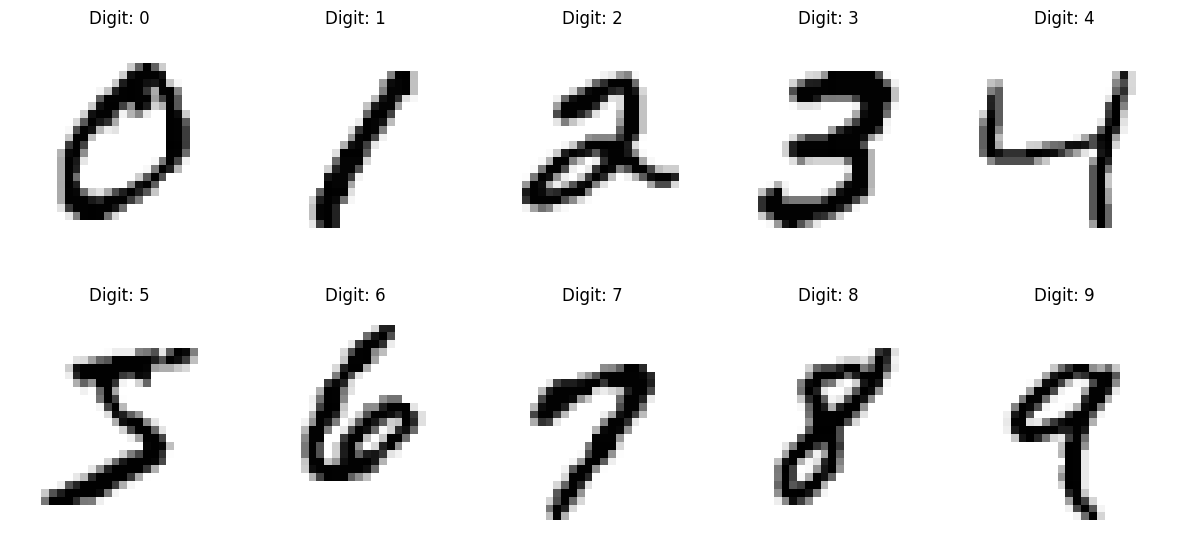

In [7]:
unique_digits_indices = {}
for i, label in enumerate(y):
    if label not in unique_digits_indices and len(unique_digits_indices) < 10:
        unique_digits_indices[label] = i
    if len(unique_digits_indices) == 10:
        break

sorted_labels = sorted(unique_digits_indices.keys(), key=lambda x: int(x))

plt.figure(figsize=(12, 6))
for i, label in enumerate(sorted_labels):
    idx = unique_digits_indices[label]
    digit_image = X[idx].reshape(28, 28)
    plt.subplot(2, 5, i + 1) # 2 filas, 5 columnas
    plt.imshow(digit_image, cmap="binary")
    plt.title(f"Digit: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Separación de entrenamiento y prueba

In [8]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test : (10000, 784) (10000,)


# Parte 2 — Clasificación multiclase

Compare **OvO** y **OvR** utilizando el mismo clasificador base.

El siguiente `SGDClassifier` es **solo un ejemplo**. Puede utilizar otro clasificador compatible si lo justifica.

In [9]:
# Cantidad de observaciones para la comparación.
# Puede modificar este valor si lo justifica.
N_TRAIN = 10000

X_train_model = X_train[:N_TRAIN]
y_train_model = y_train[:N_TRAIN]

# EJEMPLO de clasificador base.
base_clf_ovo = SGDClassifier(random_state=42)
base_clf_ovr = SGDClassifier(random_state=42)

## 6. One-vs-One (OvO)

In [10]:
modelo_ovo = OneVsOneClassifier(base_clf_ovo)

inicio_train = time.perf_counter()
modelo_ovo.fit(X_train_model, y_train_model)
tiempo_train_ovo = time.perf_counter() - inicio_train

inicio_pred = time.perf_counter()
y_pred_ovo = modelo_ovo.predict(X_test)
tiempo_pred_ovo = time.perf_counter() - inicio_pred

accuracy_ovo = accuracy_score(y_test, y_pred_ovo)

print("Accuracy OvO:", accuracy_ovo)
print("Tiempo entrenamiento OvO:", tiempo_train_ovo, "segundos")
print("Tiempo predicción OvO:", tiempo_pred_ovo, "segundos")

Accuracy OvO: 0.9089
Tiempo entrenamiento OvO: 5.50811256399993 segundos
Tiempo predicción OvO: 2.798468576000232 segundos


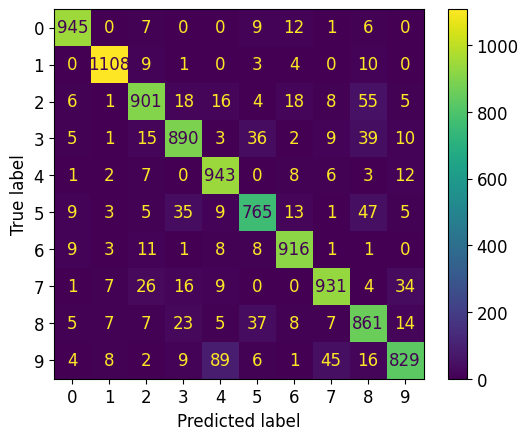

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ovo)
plt.show()

### Análisis OvO

El modelo tiene una precisoón del 90.89%. Al observar la matriz de confusión, se puede notar que algunos dígitos se confunden más que otros.

Los valores en la diagonal principal (de arriba a la izquierda a abajo a la derecha) indican las predicciones correctas. Cuanto más altos sean estos números, mejor es el modelo para identificar correctamente esa clase. Sin embargo, los valores fuera de esa diagonal son las confusiones. Como por ejemplo, el dígito 9 se confunde 14 veces con el 8.

## 7. One-vs-Rest (OvR)

In [12]:
modelo_ovr = OneVsRestClassifier(base_clf_ovr)

inicio_train = time.perf_counter()
modelo_ovr.fit(X_train_model, y_train_model)
tiempo_train_ovr = time.perf_counter() - inicio_train

inicio_pred = time.perf_counter()
y_pred_ovr = modelo_ovr.predict(X_test)
tiempo_pred_ovr = time.perf_counter() - inicio_pred

accuracy_ovr = accuracy_score(y_test, y_pred_ovr)

print("Accuracy OvR:", accuracy_ovr)
print("Tiempo entrenamiento OvR:", tiempo_train_ovr, "segundos")
print("Tiempo predicción OvR:", tiempo_pred_ovr, "segundos")

Accuracy OvR: 0.8546
Tiempo entrenamiento OvR: 16.12135605200001 segundos
Tiempo predicción OvR: 0.45260015100029705 segundos


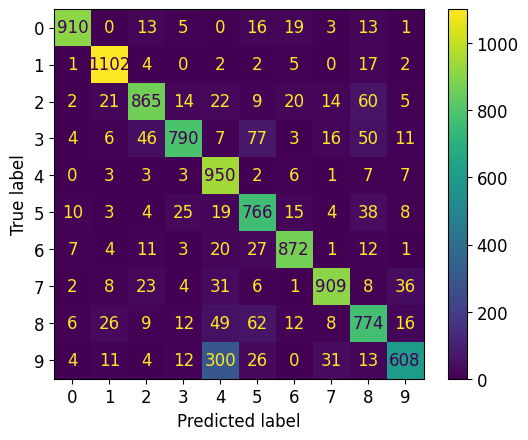

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ovr)
plt.show()

## 8. Comparación OvO vs OvR

Construya una tabla con:

- accuracy;
- tiempo de entrenamiento;
- tiempo de predicción.

In [14]:
comparacion = pd.DataFrame({
    "Estrategia": ["OvO", "OvR"],
    "Accuracy": [accuracy_ovo, accuracy_ovr],
    "Tiempo entrenamiento (s)": [tiempo_train_ovo, tiempo_train_ovr],
    "Tiempo predicción (s)": [tiempo_pred_ovo, tiempo_pred_ovr]
})

comparacion

,Estrategia,Accuracy,Tiempo entrenamiento (s),Tiempo predicción (s)
0,OvO,0.9089,5.508113,2.798469
1,OvR,0.8546,16.121356,0.452600


### Respuesta

Comente:

1. cuál obtuvo mayor accuracy;
2. cuál entrenó más rápido;
3. cuál predijo más rápido;
4. cuál considera más conveniente considerando precisión y costo computacional;
5. al menos 2 confusiones frecuentes entre dígitos.

El modelo OvO obtuvo mejor Accuracy (90.89%) frente a OvR (85.46%), siendo este mismo OvO quien también tuvo un menor tiempo de entrenamiento con 5 segúndos aprox. Sin embargo, el tiempo de predición tuvo un mejor desempeño OvR con un 0.5 s, frente a OvO con 2.8 segundos.

Desde mi punto de vista, el modelo que tuvo mejor desempeño general es OvO ya que, aunque su tiempo de predición es de apenas dos segundos más, tiene un Accuracy mejor que OvR.

OvR confundió 8  12 veces con un 3, mientras que OvO confundió el 8 23 veces con un 3.

# Parte 3 — Eliminación de ruido con KNN

## 9. Generación de imágenes con ruido

In [15]:
np.random.seed(42)

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# Generate random noise
noise_level = 100 # Adjust this value to control the intensity of the noise

# Generate noise for training set
noise_train = np.random.randint(-noise_level, noise_level + 1, size=X_train.shape)
X_train_noisy = X_train_clean + noise_train
X_train_noisy = np.clip(X_train_noisy, 0, 255) # Clip values to be within 0-255

# Generate noise for test set
noise_test = np.random.randint(-noise_level, noise_level + 1, size=X_test.shape)
X_test_noisy = X_test_clean + noise_test
X_test_noisy = np.clip(X_test_noisy, 0, 255) # Clip values to be within 0-255

print("X_train_noisy shape:", X_train_noisy.shape)
print("X_test_noisy shape:", X_test_noisy.shape)

X_train_noisy shape: (60000, 784)
X_test_noisy shape: (10000, 784)


## 10. Visualización del ruido

Muestre al menos 5 pares:

**Imagen limpia → Imagen con ruido**

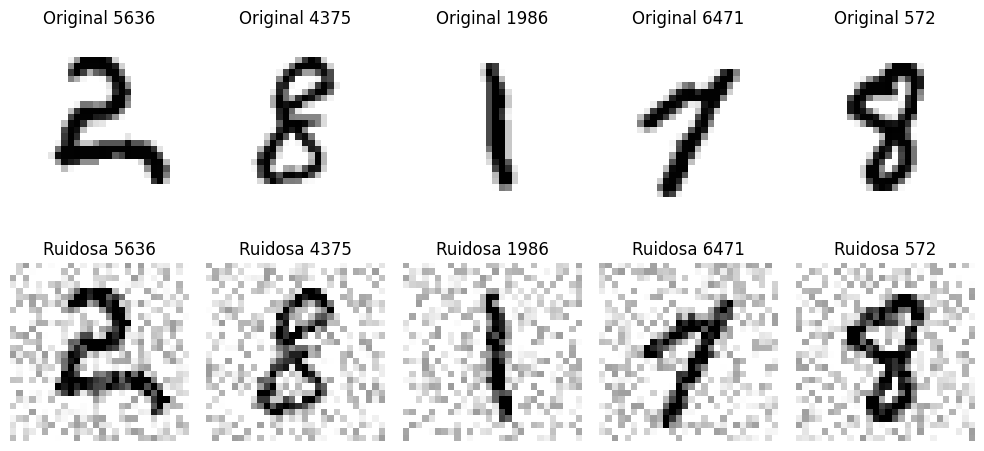

In [16]:
n_samples = 5
random_indices = np.random.randint(0, len(X_test_clean), n_samples)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(random_indices):
    # Clean Image
    plt.subplot(2, n_samples, i + 1)
    plot_digit(X_test_clean[idx], title=f"Original {idx}")

    # Noisy Image
    plt.subplot(2, n_samples, i + n_samples + 1)
    plot_digit(X_test_noisy[idx], title=f"Ruidosa {idx}")

plt.tight_layout()
plt.show()

## 11. KNN multisalida

Entrene un `KNeighborsClassifier` donde:

- entrada = imagen con ruido;
- salida = imagen limpia.

La salida contiene los 784 píxeles que se deben reconstruir.

In [17]:
N_KNN = 5000

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_noisy[:N_KNN], X_train_clean[:N_KNN])

KNeighborsClassifier()

## 12. Reconstrucción

Reconstruya al menos 5 imágenes del conjunto de prueba.

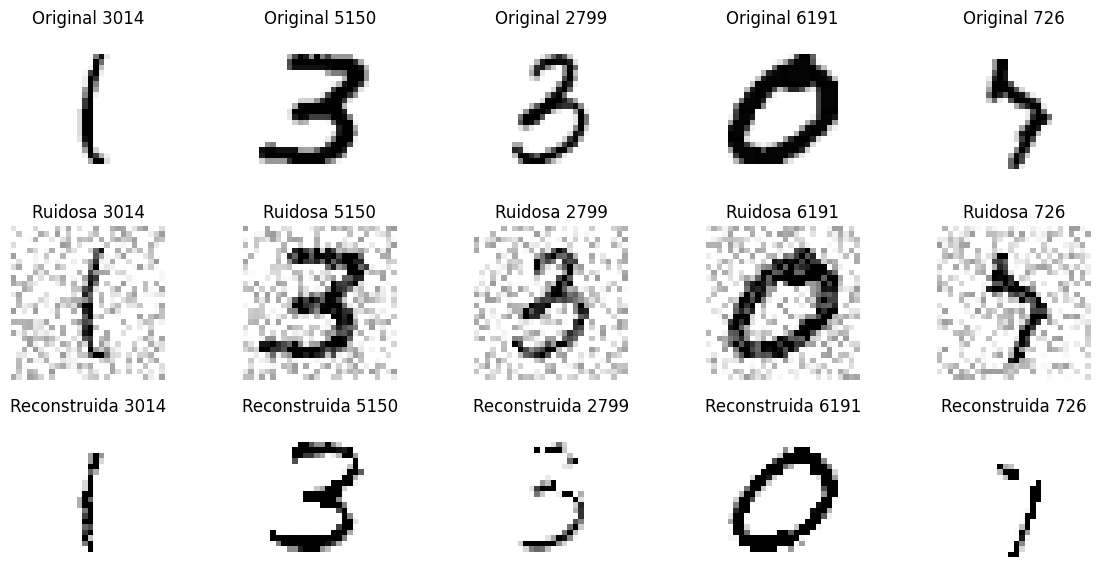

In [18]:
n_samples_reconstruct = 5
random_indices_reconstruct = np.random.randint(0, len(X_test_noisy), n_samples_reconstruct)

X_test_noisy_subset = X_test_noisy[random_indices_reconstruct]
clean_digits = knn_clf.predict(X_test_noisy_subset)

plt.figure(figsize=(12, 6))
for i in range(n_samples_reconstruct):
    # Original Clean Image
    plt.subplot(3, n_samples_reconstruct, i + 1)
    plot_digit(X_test_clean[random_indices_reconstruct[i]], title=f"Original {random_indices_reconstruct[i]}")

    # Noisy Image
    plt.subplot(3, n_samples_reconstruct, i + n_samples_reconstruct + 1)
    plot_digit(X_test_noisy[random_indices_reconstruct[i]], title=f"Ruidosa {random_indices_reconstruct[i]}")

    # Reconstructed Image
    plt.subplot(3, n_samples_reconstruct, i + 2 * n_samples_reconstruct + 1)
    plot_digit(clean_digits[i], title=f"Reconstruida {random_indices_reconstruct[i]}")

plt.tight_layout()
plt.show()

### Análisis

El clasificador KNN multisalida ha realizado un trabajo razonable en la eliminación de ruido de las imágenes. Al comparar las imágenes originales, las ruidosas y las reconstruidas, se puede comentar que hay una clara reducción del ruido presente en las imágenes ruidosas. El algoritmo suavizó los píxeles y ha intentado restaurar la forma original del dígito. En la mayoría de los casos la forma original de los dígitos se ha mantenido evidenciando que el KNN es capaz de identificar patrones visuales incluso con la presencia de ruido y aunque este mismo se reduce esto debido a que KNN promedia los valores de los vecimos más cercanos, razón por la que se pueden difuminar los detalles finos.]

# Parte 4 — Prueba con una imagen nueva

## 13. Carga y preprocesamiento

Original image size: (512, 512)
Processed image shape (vector): (1, 784)


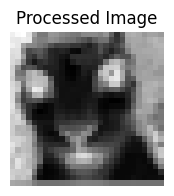

In [19]:
from PIL import Image

RUTA_IMAGEN = "/content/ojosgato.png"

# Open the image
img = Image.open(RUTA_IMAGEN)

# Convert to grayscale
img_gray = img.convert('L')

# Resize to 28x28
img_resized = img_gray.resize((28, 28))

img_np = np.array(img_resized)

img_vector = img_np.reshape(1, 784)

print("Original image size:", img.size)
print("Processed image shape (vector):", img_vector.shape)

# Display the processed image to check its appearance
plt.figure(figsize=(2, 2))
plot_digit(img_vector[0], title="Processed Image")
plt.show()

Noisy image shape: (1, 784)


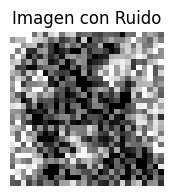

In [20]:
# Generate a noisy version of the preprocessed image vector
noise_level = 100
noise_custom = np.random.randint(-noise_level, noise_level + 1, size=img_vector.shape)
img_noisy = img_vector + noise_custom
img_noisy = np.clip(img_noisy, 0, 255)

print("Noisy image shape:", img_noisy.shape)

# Display the noisy image
plt.figure(figsize=(2, 2))
plot_digit(img_noisy[0], title="Imagen con Ruido")
plt.show()

In [21]:
# Use knn_clf to reconstruct the noisy image
img_reconstructed = knn_clf.predict(img_noisy)

print("Reconstructed image shape:", img_reconstructed.shape)

Reconstructed image shape: (1, 784)


## 14. Resultado final

Muestre:

**Imagen original → Imagen 28×28 → Con ruido → Reconstruida**

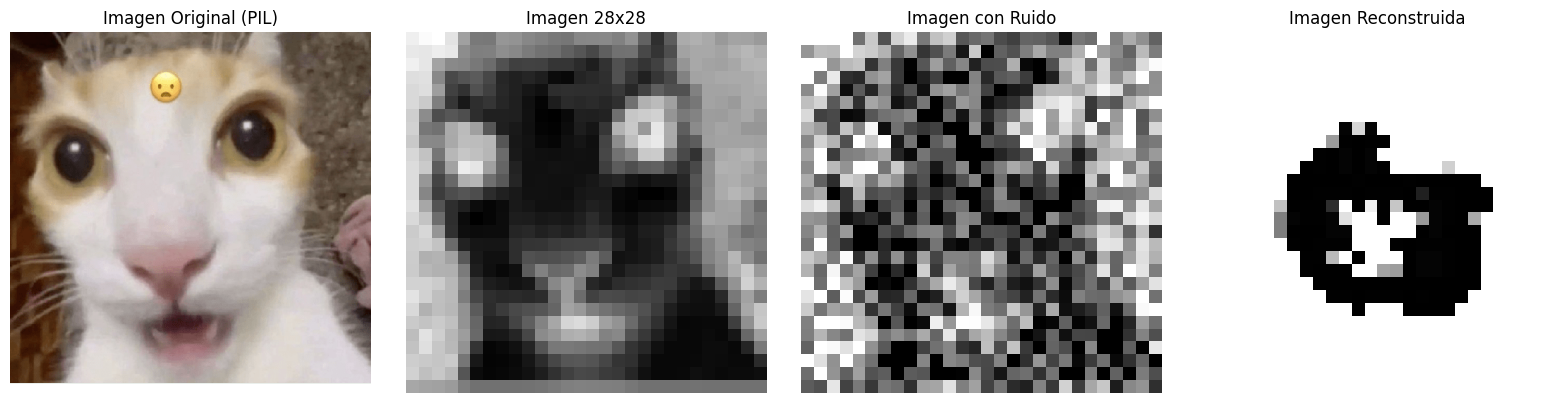

In [22]:
plt.figure(figsize=(16, 4))

# Original Image (from PIL, as a larger image if available, otherwise just text)
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Imagen Original (PIL)")
plt.axis("off")

# Processed 28x28 Image
plt.subplot(1, 4, 2)
plot_digit(img_vector[0], title="Imagen 28x28")

# Noisy Image
plt.subplot(1, 4, 3)
plot_digit(img_noisy[0], title="Imagen con Ruido")

# Reconstructed Image
plt.subplot(1, 4, 4)
plot_digit(img_reconstructed[0], title="Imagen Reconstruida")

plt.tight_layout()
plt.show()

# Conclusiones

Responda brevemente:

1. ¿Qué relación existe entre una imagen de 28×28 y un vector de 784 elementos?
Una imagen de 28x28 pixeles tiene un total de 28*28 = 784 píxeles mientras que un vector de 784 elementos es una representación aplanada de esta imagen, donde cada elemento del vector corresónde a la intensidad de un píxel de la imagen. Basicamente es una forma diferente de estructurar los mismo datos visuales.

2. ¿Qué representa el tensor `(70000, 28, 28)`?
Representa un conjunto de 70000 imágenes individuales. Cada imagen dentro de este conjunto es una matriz bidimensional de 28x28 píxeles.
3. ¿Qué diferencia práctica observó entre OvO y OvR en accuracy y tiempo?
OvO obtuvo una precisión más alta en comparación con OvR, también, OvO fue significativamente más en el entrenamiento que OvR, sin emabrgo. OvR fue más rápido en la predicción que OvO. PAra el conjunto de datos OvO mostró una mejor precisón y un entrenamiento más rápido mientras que OvR ofreció una predición más veloz.
4. ¿Cómo puede KNN utilizarse para reconstruir una imagen con ruido?
KNN se utilizó como modelo multisalida, donde se entrenó con pares de datos. Cuando se le presenta una nueva imagen ruidosa, el modelo KNN busca los K vecinos más cercanos en su conjunto de entrenamiento basándose en la similitud de las imágenes ruidosas. Luego, al reconstruir la imagen devuelve la imagen limpia correspondiente a esos vecios más cercanos. De esta manera, el modelo aprende a mapear patrones de ruido a sus contrapartes limpias.
5. ¿Qué dificultad encontró al utilizar una imagen externa a MNIST?
La principál dificultad al utilizar una imagen fue la necesidad de preprocesarla para que coincidera con el formato y las caracteristicas de las imagenes mnist. Con esto me refiero a elegir una imagen que se viera bien al ser convertida en escala de grises, luego al redimensionalar a 28x28 pixeles se perdió muchisimo la calidad, y luego, fue entrenado con vectores de 784 elementos, requiriendo que la imagen 28x28 fuera aplanada. Finalmente, al aplicar el modelo a una imagen que no es un dígito, como la imagen de un fato, la reconstrucción puede ser más abstracta y no representar claramente el contenido origianl, ya que el modelo no ha visto ejemplos similares durante su entrenamiento.
